# <p style = "text-align:center">**Advance Visualization with Seaborn**

## Plotting with Seaborn

Seaborn is a Python visualization library based on matplotlib. It provides a high-level interface for drawing attractive statistical graphics. 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.style.use('ggplot')  # for ggplot-like style

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')


## Fetching Data<a id="1"></a>

Dataset: Immigration to Canada from 1980 to 2013 - [International migration flows to and from selected countries - The 2015 revision](https://www.un.org/development/desa/pd/data/international-migration-flows) from United Nation's website

In this lab, focus will be on the Canadian Immigration data and use the **already cleaned dataset** from previous lab 

In [2]:
df_can = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Canada.csv')
df_can.head()

,Country,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
0,Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
1,Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,...,1223,856,702,560,716,561,539,620,603,15699
2,Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
3,American Samoa,Oceania,Polynesia,Developing regions,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
4,Andorra,Europe,Southern Europe,Developed regions,0,0,0,0,0,0,...,0,1,1,0,0,0,0,1,1,15


The default index of the dataset is a numeric range from 0 to 194. This makes it very difficult to do a query by a specific country. For example to search for data on Haiti, there is need to know the corresponding index value.

This can be fixed by setting the 'Country' column as the index

In [3]:
df_can.set_index('Country', inplace=True)
df_can.head(3)

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,1,...,1223,856,702,560,716,561,539,620,603,15699
Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,69,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439


In [4]:
# removing the name of the index
df_can.index.name = None
df_can.head(3)

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,1,...,1223,856,702,560,716,561,539,620,603,15699
Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,69,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439


Declaring a variable that will allow easy call upon the full range of years:

In [5]:
years = list(map(str, range(1980, 2014)))

### Categorical Plots
Continents are mentioned in the data 'df_can'

In [6]:
df_can['Continent'].unique()

array(['Asia', 'Europe', 'Africa', 'Oceania',
       'Latin America and the Caribbean', 'Northern America'],
      dtype=object)

<Axes: xlabel='Continent', ylabel='count'>

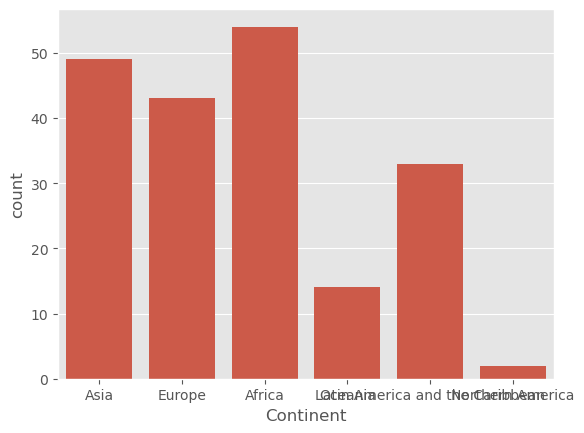

In [7]:
sns.countplot(x='Continent', data=df_can)

Replacing the Latin America and the Caribbean' with and "L-America", 'Northern America' with "N-America", and change the figure size

In [8]:
df_can = df_can.replace('Latin America and the Caribbean', 'L-America')
df_can = df_can.replace('Northern America', 'N-America')

In [9]:
df_can['Continent'].unique()

array(['Asia', 'Europe', 'Africa', 'Oceania', 'L-America', 'N-America'],
      dtype=object)

<Axes: xlabel='Continent', ylabel='count'>

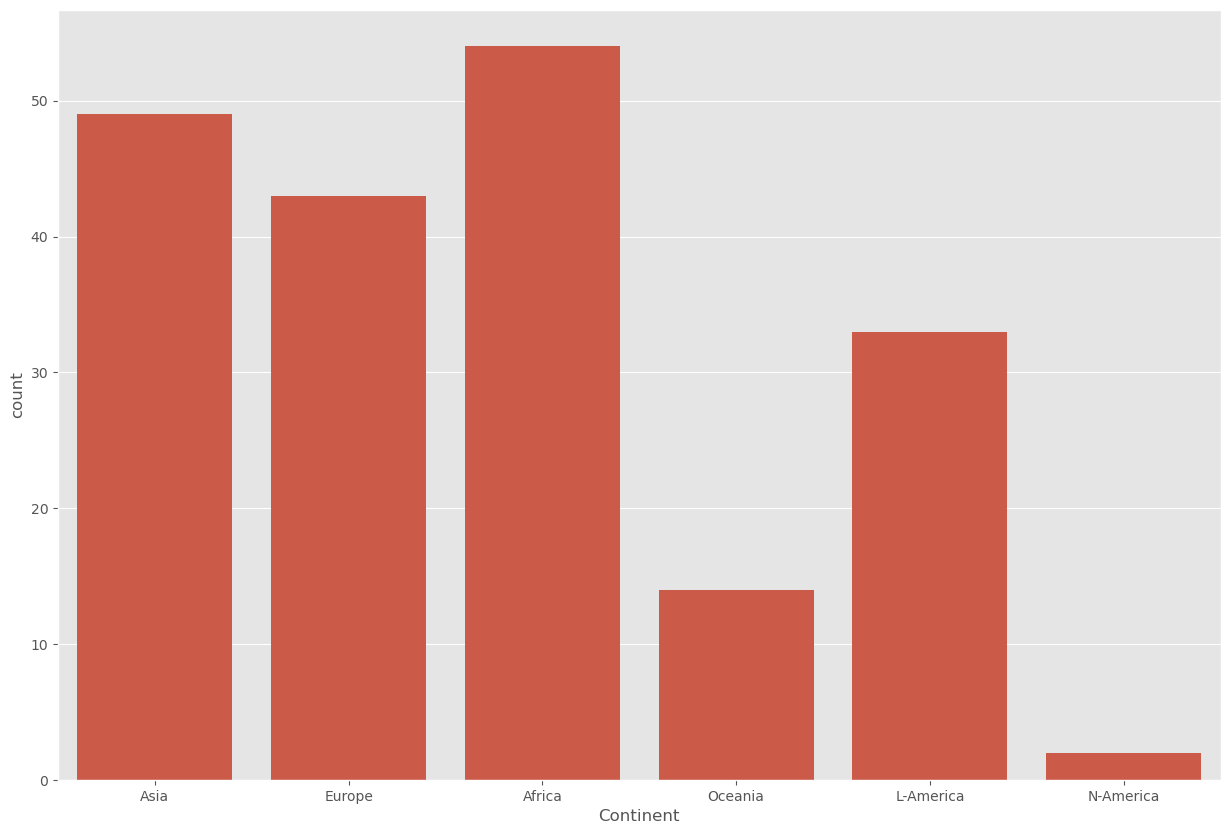

In [10]:
plt.figure(figsize=(15, 10))
sns.countplot(x='Continent', data=df_can)

### Barplot

**This plot will perform the Groupby on a categorical varaible and plot aggregated values, with confidence intervals**.

Plotting the total immigrants Continent-wise


<Axes: xlabel='Continent', ylabel='Total'>

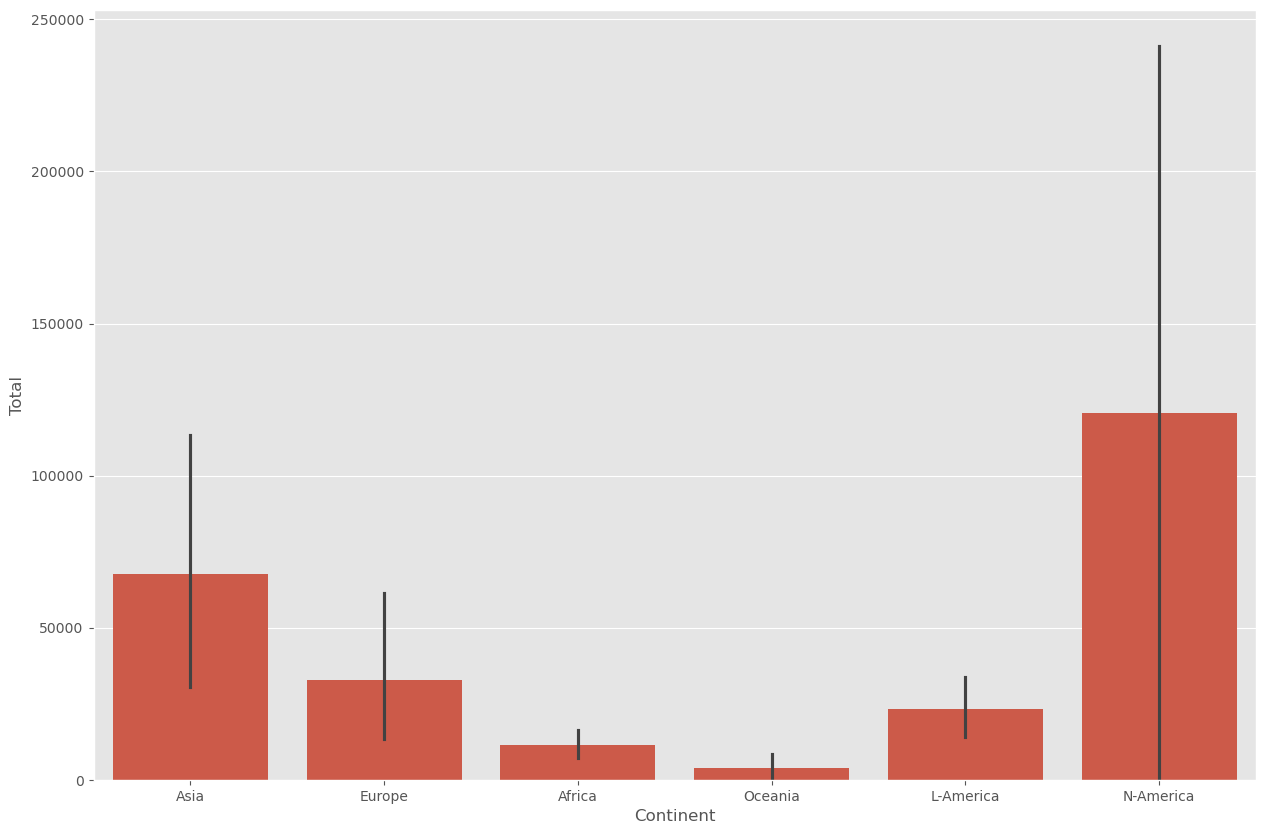

In [11]:
plt.figure(figsize=(15, 10))
sns.barplot(x='Continent', y='Total', data=df_can)

Verifying the values by performing the groupby on the Total and Continent for mean()

In [12]:
df_Can=df_can.groupby('Continent')['Total'].mean()
df_Can

Continent
Africa        11462.000000
Asia          67710.081633
Europe        32812.720930
L-America     23186.303030
N-America    120571.000000
Oceania        3941.000000
Name: Total, dtype: float64

Creating a new dataframe that stores the total number of landed immigrants to Canada per year from 1980 to 2013.

In [13]:
# DF for the total population per year
df_tot = pd.DataFrame(df_can[years].sum(axis=0))

# changing the years to type float (useful for regression later on)
df_tot.index = map(float, df_tot.index)

# resetting the index to put in back in as a column in the df_tot dataframe
df_tot.reset_index(inplace=True)

# renaming columns
df_tot.columns = ['year', 'total']

# the final dataframe
df_tot.head()

,year,total
0,1980.0,99137
1,1981.0,110563
2,1982.0,104271
3,1983.0,75550
4,1984.0,73417


### Generating Regression Plot

<Axes: xlabel='year', ylabel='total'>

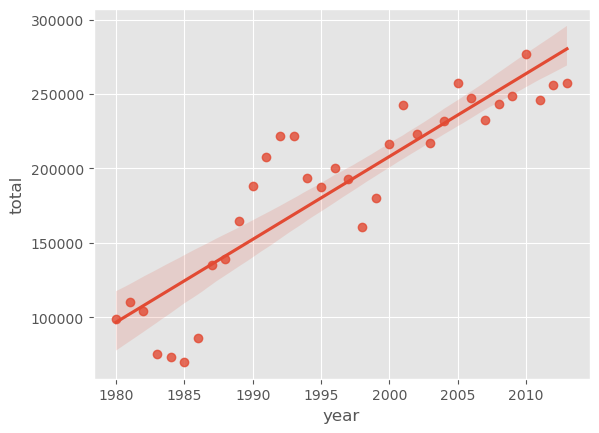

In [14]:
sns.regplot(x='year', y='total', data=df_tot)

Customizing the plot

+ Increasing the size of the plot.
+ Marker shape is changed to `+` instead of circular markers and the size is also increased.
+ Color is changed to green.
+ Adding a title and x- and y-labels.


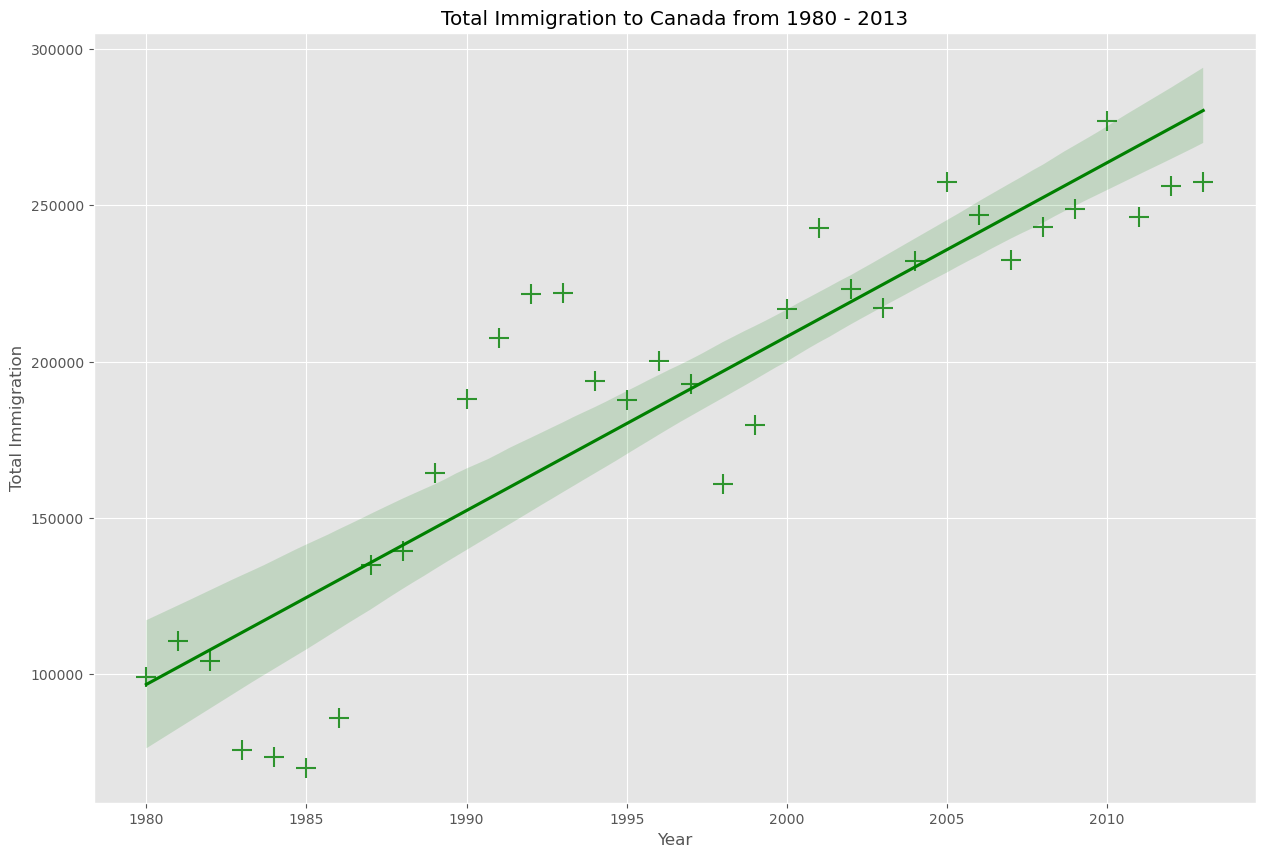

In [15]:
plt.figure(figsize=(15, 10))
ax = sns.regplot(x='year', y='total', data=df_tot, color='green', marker='+', scatter_kws={'s': 200})

ax.set(xlabel='Year', ylabel='Total Immigration') 
ax.set_title('Total Immigration to Canada from 1980 - 2013') 
plt.show()

Changing the plot to white plain background

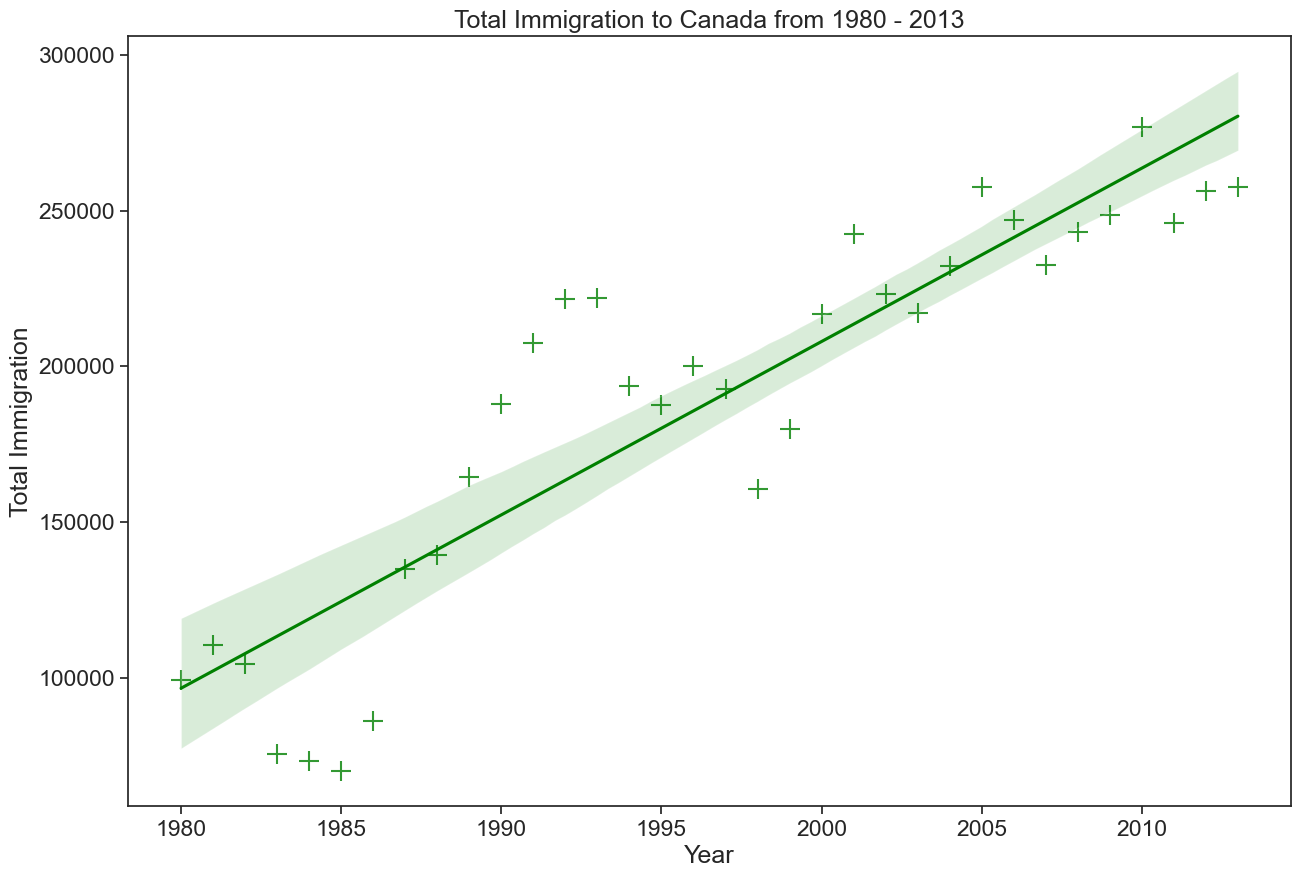

In [16]:
plt.figure(figsize=(15, 10))

sns.set(font_scale=1.5)
sns.set_style('ticks')  # change background to white background

ax = sns.regplot(x='year', y='total', data=df_tot, color='green', marker='+', scatter_kws={'s': 200})
ax.set(xlabel='Year', ylabel='Total Immigration')
ax.set_title('Total Immigration to Canada from 1980 - 2013')
plt.show()

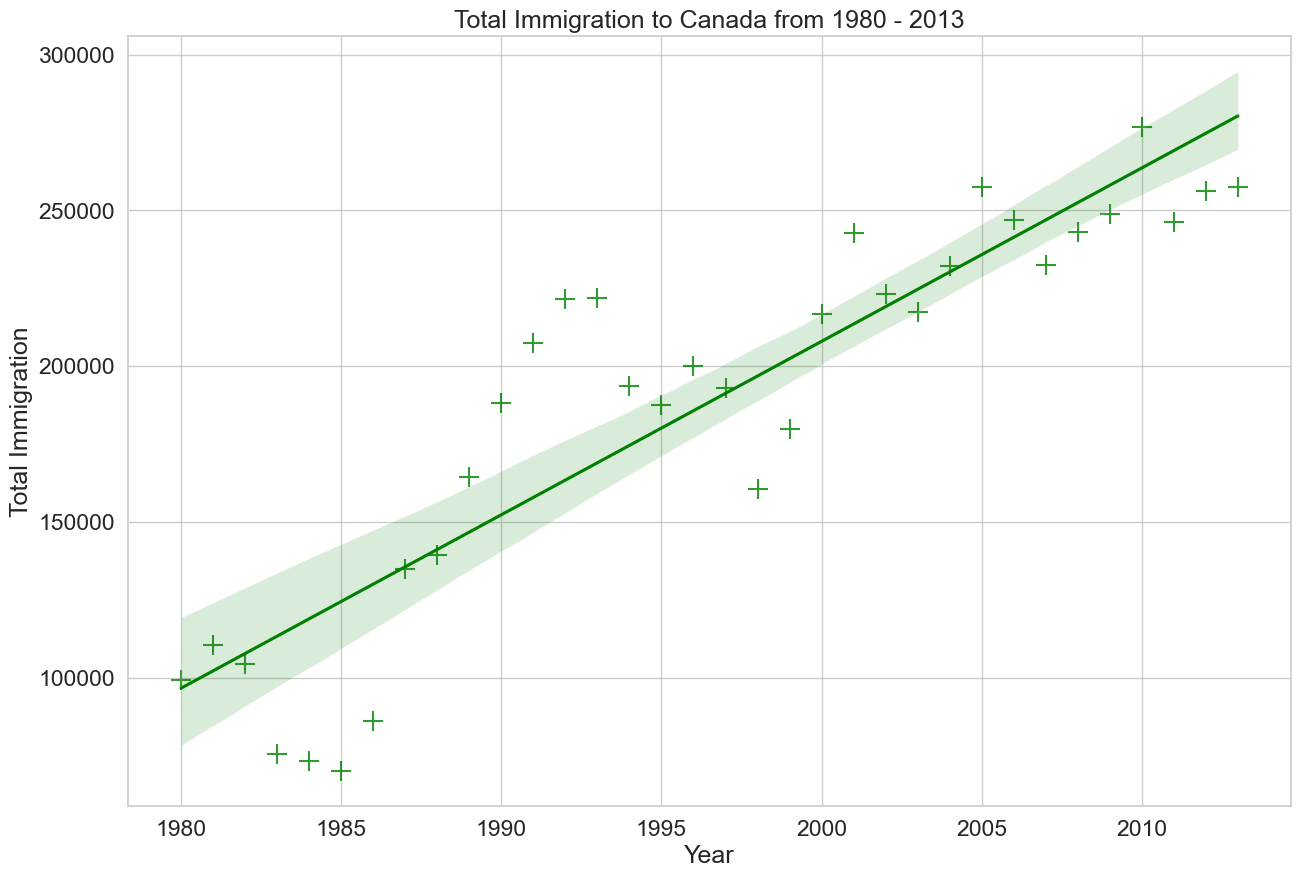

In [17]:
# White background with grids
plt.figure(figsize=(15, 10))

sns.set(font_scale=1.5)
sns.set_style('whitegrid')

ax = sns.regplot(x='year', y='total', data=df_tot, color='green', marker='+', scatter_kws={'s': 200})
ax.set(xlabel='Year', ylabel='Total Immigration')
ax.set_title('Total Immigration to Canada from 1980 - 2013')
plt.show()

Creating a scatter plot with a regression line to visualize the total immigration from Denmark, Sweden, and Norway to Canada from 1980 to 2013.

Text(0.5, 1.0, 'Total Immigrationn from Denmark, Sweden, and Norway to Canada from 1980 - 2013')

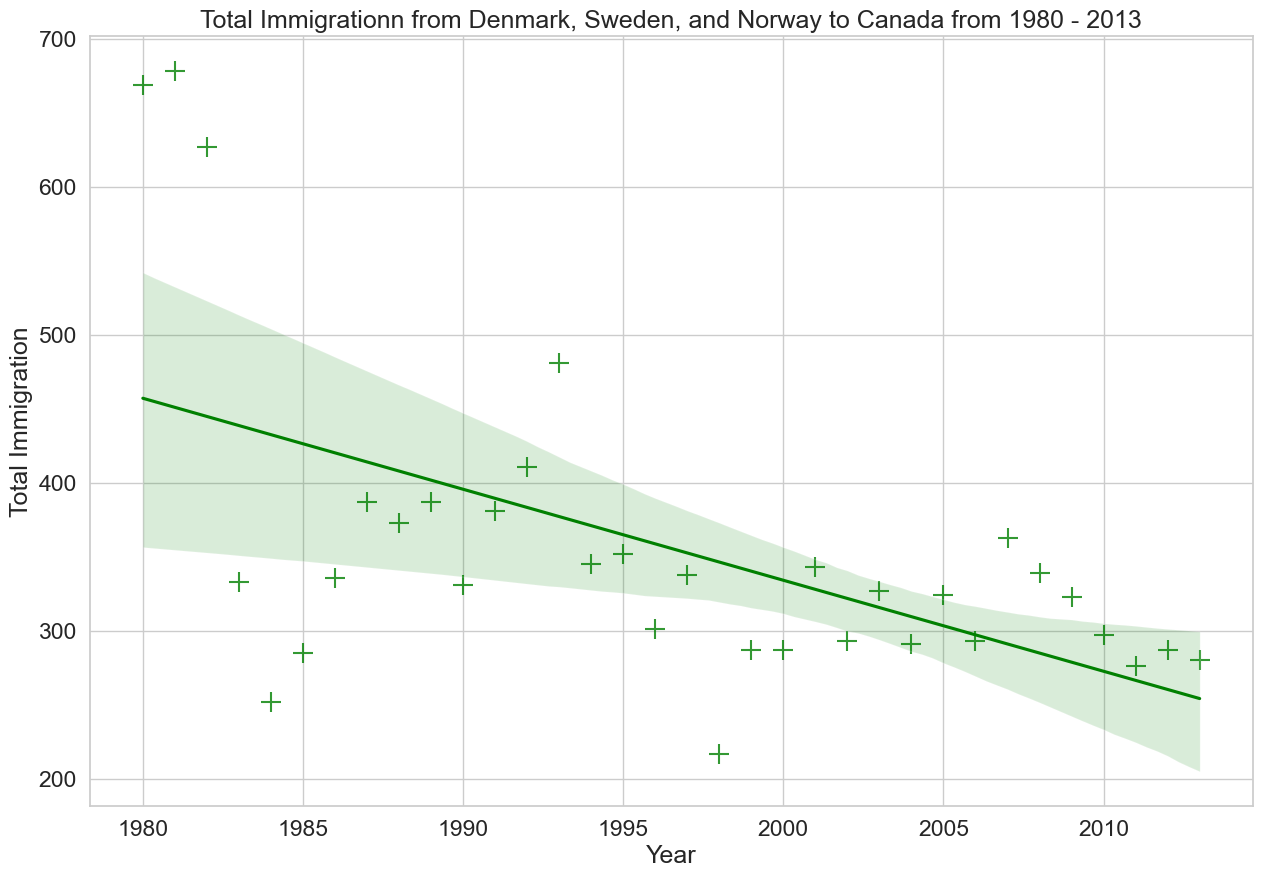

In [18]:
df_countries = df_can.loc[['Denmark', 'Norway', 'Sweden'], years].transpose()

# creating df_total by summing across three countries for each year
df_total = pd.DataFrame(df_countries.sum(axis=1))

# resetting index in place
df_total.reset_index(inplace=True)

# renaming columns
df_total.columns = ['year', 'total']

# changing column year from string to int to create scatter plot
df_total['year'] = df_total['year'].astype(int)


plt.figure(figsize=(15, 10))

# defining background style and font size
sns.set(font_scale=1.5)
sns.set_style('whitegrid')

# generating plot and add title and axes labels
ax = sns.regplot(x='year', y='total', data=df_total, color='green', marker='+', scatter_kws={'s': 200})
ax.set(xlabel='Year', ylabel='Total Immigration')
ax.set_title('Total Immigrationn from Denmark, Sweden, and Norway to Canada from 1980 - 2013')